## End 2 End ML life cycle

    - Problem definition
    - Data Collection
    - Data Cleaning and preprocessing
    - EDA
    - Feature Engineering & selection
    - Model Selection
    - Model Training
    - Model Evaluation and Tuning
    - Model Deployment
    - Montoring & Maintenance

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

### 1. Problem Definition

In [ ]:
# Goal: Classify movie reviews as positive (1) or negative (0) based on text sentiment.
# Application: This can be used for review analysis, customer feedback systems, or recommendation engines.

### 2. Data Collection

#### The dataset consists of 20 manually curated movie reviews with sentiment labels (1 = positive, 0 = negative).
#### In a real-world scenario, data might be scraped from IMDb, Rotten Tomatoes, or collected via APIs.

In [35]:
data = {
    "review": [
        "I loved this movie! The plot was fantastic and the acting was great.",
        "Terrible movie. Waste of time. Would not recommend.",
        "An average movie, had some good moments but mostly boring.",
        "Absolutely amazing! A must-watch for everyone.",
        "I didn't like this movie at all. The story was too slow and predictable.",
        "Best movie I have seen in years!", 
        "Horrible, just horrible. Could not sit through it.",
        "A beautiful story told in a fantastic way.",
        "Disappointed. I had high hopes but it was a letdown.",
        "Great performance by the lead actor!", 
        "Not worth the hype. Overrated.",
        "A masterpiece! Must watch.",
        "Fell asleep halfway. Boring.",
        "The cinematography was stunning!", 
        "Terrible script and bad direction.",
        "Enjoyed every moment!", 
        "Predictable and cliché.",
        "One of the best movies ever!", 
        "Would not recommend. Waste of time.",
        "Amazing soundtrack and emotional scenes."
    ],
    "sentiment": [1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}
df = pd.DataFrame(data)
df

,review,sentiment
0,I loved this movie! The plot was fantastic and...,1
1,Terrible movie. Waste of time. Would not recom...,0
2,"An average movie, had some good moments but mo...",0
3,Absolutely amazing! A must-watch for everyone.,1
4,I didn't like this movie at all. The story was...,0
5,Best movie I have seen in years!,1
6,"Horrible, just horrible. Could not sit through...",0
7,A beautiful story told in a fantastic way.,1
8,Disappointed. I had high hopes but it was a le...,0
9,Great performance by the lead actor!,1


### 3. Data Cleaning and Preprocessing

#### Convert text into numerical representations using TF-IDF Vectorization.
#### Removes stop words, punctuation, and converts words to lowercase
                                                 bad	is	love	movie	this
                 Review 1 ("I love this movie")	0.000	0.000	0.705	0.502	0.502
                 Review 2 ("This movie is bad")	0.576	0.576	0.000	0.410	0.410

In [ ]:
vectorizer = TfidfVectorizer(stop_words=None)
X = vectorizer.fit_transform(df['review'])
y = df['sentiment']

In [37]:
### feature names

In [38]:
feature_names = vectorizer.get_feature_names_out()
print("Features ")
print(feature_names)
print("Length")
print(len(feature_names))

Features 
['absolutely' 'acting' 'actor' 'all' 'amazing' 'an' 'and' 'asleep' 'at'
 'average' 'bad' 'beautiful' 'best' 'boring' 'but' 'by' 'cinematography'
 'cliché' 'could' 'didn' 'direction' 'disappointed' 'emotional' 'enjoyed'
 'ever' 'every' 'everyone' 'fantastic' 'fell' 'for' 'good' 'great' 'had'
 'halfway' 'have' 'high' 'hopes' 'horrible' 'hype' 'in' 'it' 'just' 'lead'
 'letdown' 'like' 'loved' 'masterpiece' 'moment' 'moments' 'mostly'
 'movie' 'movies' 'must' 'not' 'of' 'one' 'overrated' 'performance' 'plot'
 'predictable' 'recommend' 'scenes' 'script' 'seen' 'sit' 'slow' 'some'
 'soundtrack' 'story' 'stunning' 'terrible' 'the' 'this' 'through' 'time'
 'told' 'too' 'was' 'waste' 'watch' 'way' 'worth' 'would' 'years']
Length
84


In [39]:
X.todense()[0]

matrix([[0.        , 0.31779023, 0.        , 0.        , 0.        ,
         0.        , 0.2136156 , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.27934247, 0.        , 0.        ,
         0.        , 0.27934247, 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.31779023, 0.        , 0.        , 0.        , 0.        ,
         0.2136156 , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.31779023, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.39799689, 0

In [40]:
y[0:5]

0    1
1    0
2    0
3    1
4    0
Name: sentiment, dtype: int64

In [ ]:
### 4. Exploratory Data Analysis (EDA)

In [ ]:
#### Check the distribution of positive vs. negative reviews

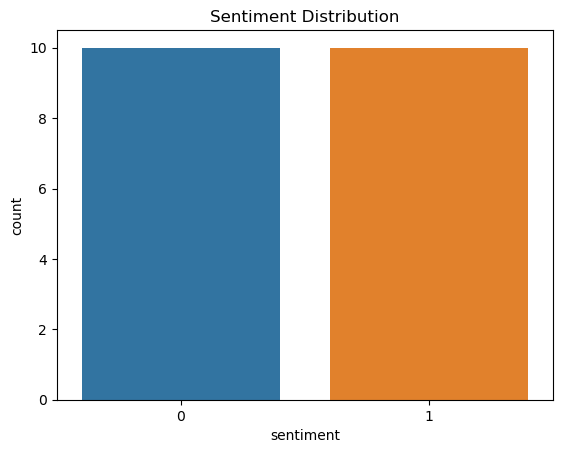

In [43]:
sns.countplot(x=df["sentiment"])
plt.title("Sentiment Distribution")
plt.show()

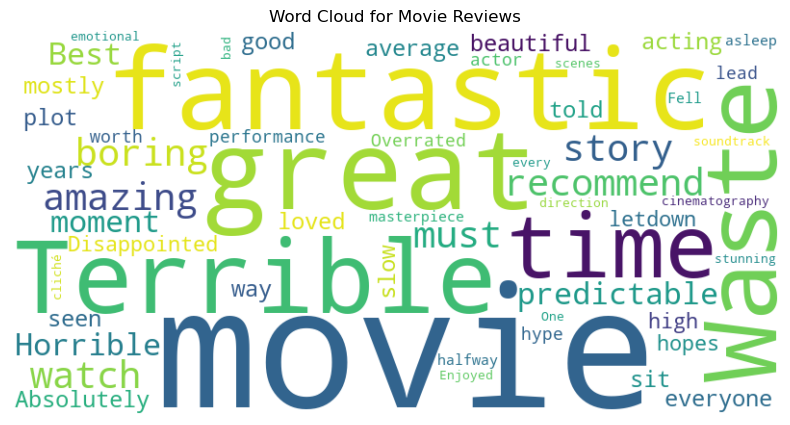

In [60]:
from wordcloud import WordCloud
# Generate Word Cloud
text = " ".join(df['review'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot Word Cloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Movie Reviews")
plt.show()

#### 5. Feature Engineering & Selection
        We used TF-IDF to select important words, but additional techniques like N-grams, POS tagging, and word embeddings (Word2Vec, BERT) can be used.

### 6. Model Selection
        using Random forest model
        Train and Test split - 80% and 20%

In [46]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier()
model

RandomForestClassifier()

### 7. Model Training

In [48]:
model.fit(X_train, y_train)

RandomForestClassifier()

#### save the model and the vectorizer

In [56]:
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['old_data_distribution.pkl']

### 8. Model Evaluation and Tuning
    Performance Metrics: Accuracy, Precision, Recall, F1-score

In [49]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5
Classification Report:
               precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       1.00      0.33      0.50         3

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4

Confusion Matrix:
 [[1 0]
 [2 1]]


In [53]:
param_grid = {
    'n_estimators': [50, 100, 200],   # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of each tree (None means nodes expand until leaves are pure)
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]     # Minimum samples required to be at a leaf node
}
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Best Model
model = grid_search.best_estimator_

# 5. Model Training
model.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


RandomForestClassifier(max_depth=10, n_estimators=200)

In [55]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5
Classification Report:
               precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       1.00      0.33      0.50         3

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4

Confusion Matrix:
 [[1 0]
 [2 1]]


### 9. Model Deployment (FastAPI Backend & Streamlit UI)
    FastAPI serves the model via an API endpoint:
    movies_fastapi_app.py
    Streamlit act as UI for movie reviewing app
    movies_stramlit_app.py

In [ ]:
### 10. Monitoring & Maintenance
    Monitor Model Performance:

    Set up logging (e.g., FastAPI logs, monitoring dashboards).
    Track accuracy drift by periodically checking real-world data vs. model predictions.
    Model Retraining Strategy:

    Periodic retraining with fresh user reviews.
    Active learning: Ask users for feedback (e.g., "Was this prediction correct?").
    Deployment Maintenance:

    API uptime monitoring using Prometheus/Grafana.
    Dockerize and deploy using Kubernetes or AWS Lambda for scalability.
